In [1]:
# -----------------------------------------
# Task 1 — Data Exploration with Pandas
# -----------------------------------------

import pandas as pd

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)
pd.set_option("display.expand_frame_repr", False)

# Load Dataset
df = pd.read_csv("students.csv")

# 1. Print first 5 rows
print("First 5 Rows:")
print(df.head())

# 2. Print Shape and Datatypes
print("\nShape of Dataset:")
print(df.shape)

print("\nData Types:")
print(df.dtypes)

# 3. Summary Statistics
print("\nSummary Statistics:")
print(df.describe())

# 4. Count Pass vs Fail
result_counts = df["passed"].value_counts()

passed_count = result_counts.get(1, 0)
failed_count = result_counts.get(0, 0)

print("\nStudent Result Summary")
print("----------------------")
print(f"Number of students who passed : {passed_count}")
print(f"Number of students who failed : {failed_count}")

# 5. Avrage score per Subject for pass and fail students

subject_cols = ["math", "science", "english", "history", "pe"]

pass_avg = df[df["passed"]==1][subject_cols].mean()
fail_avg = df[df["passed"]==0][subject_cols].mean()

print("\nAverage scores for passing students:")
print(pass_avg)

print("\nAverage scores for Failing students:")
print(fail_avg)

# 6. Student with highest overall average

df["overall_avg"] = df[subject_cols].mean(axis=1)

top_student = df.loc[df["overall_avg"].idxmax()]

print("\nStudent with highest overall average:")
print(top_student["name"])
print("Average:", top_student["overall_avg"])

First 5 Rows:
      name  math  science  english  history  pe  attendance_pct  study_hours_per_day  passed
0    Alice    88       92       76       80  95              92                  4.5       1
1      Bob    42       55       48       50  60              65                  1.2       0
2  Charlie    75       70       80       68  88              85                  3.0       1
3    Diana    95       98       91       89  97              98                  6.0       1
4      Eve    38       42       50       45  55              58                  0.8       0

Shape of Dataset:
(15, 9)

Data Types:
name                       str
math                     int64
science                  int64
english                  int64
history                  int64
pe                       int64
attendance_pct           int64
study_hours_per_day    float64
passed                   int64
dtype: object

Summary Statistics:
            math    science    english    history         pe  attendance_p

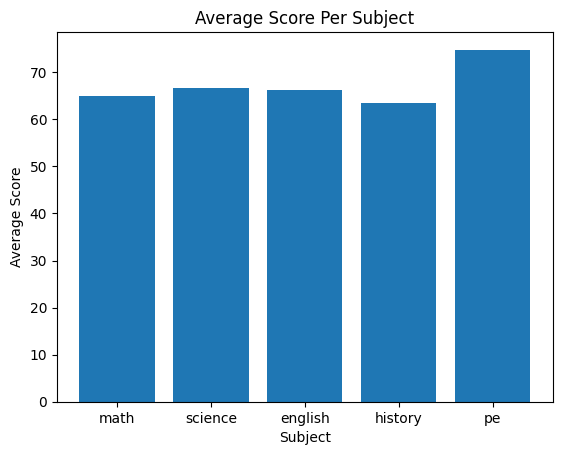

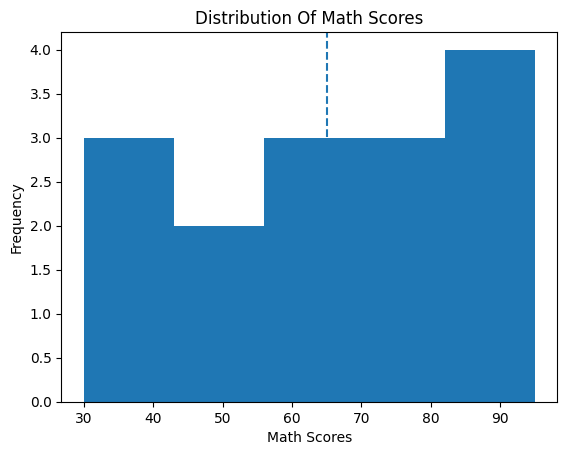

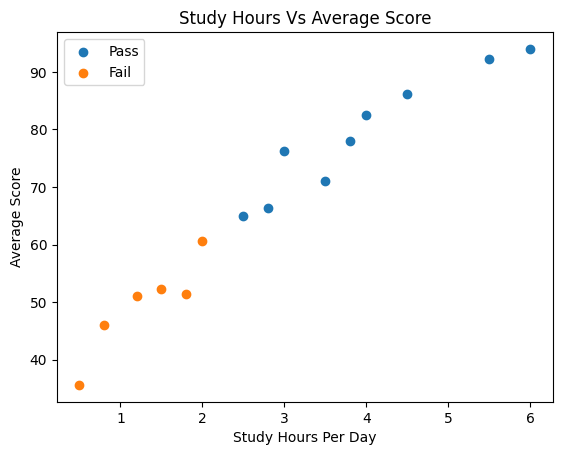

C:\Users\plsha\AppData\Local\Temp\ipykernel_10428\1463239993.py:68: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


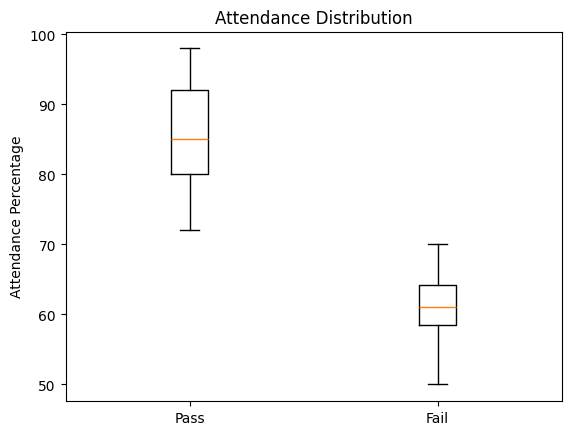

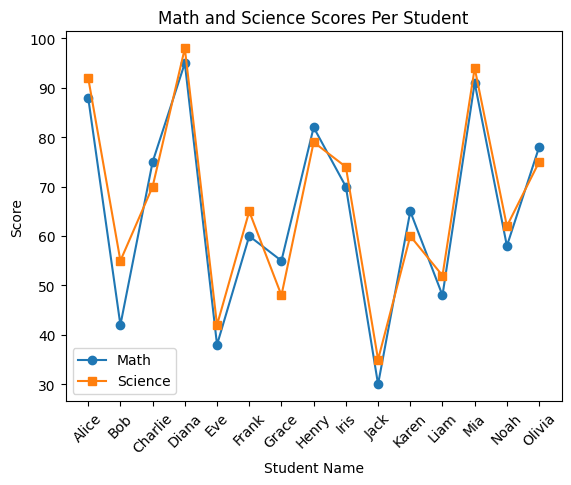

In [ ]:
# -----------------------------------------------
# Task 2 — Data Visualization with Matplotlib
# -----------------------------------------------

import matplotlib.pyplot as plt

# Add Avg_score column
df["avg_score"] = df[subject_cols].mean(axis=1)

# 1. Bar Chart - Average score per subject

subject_means = df[subject_cols].mean()

plt.figure()
plt.bar(subject_cols, subject_means)
plt.title("Average Score Per Subject")
plt.xlabel("Subject")
plt.ylabel("Average Score")
plt.savefig("plot1_bar.png")
plt.show()

# 2. Histogram - Math Distribution

mean_math = df["math"].mean()

plt.figure()
plt.hist(df["math"], bins=5)
plt.axvline(mean_math , linestyle="dashed")
plt.title("Distribution Of Math Scores")
plt.xlabel("Math Scores")
plt.ylabel("Frequency")
plt.savefig("plot2_histogram.png")

# 3. Scatter Plot - Study Hours vs Average Scores

pass_students = df[df["passed"] == 1]
fail_students = df[df["passed"] == 0]

plt.figure()

plt.scatter(
    pass_students["study_hours_per_day"],
    pass_students["avg_score"],
    label = "Pass"
)

plt.scatter(
    fail_students["study_hours_per_day"],
    fail_students["avg_score"],
    label = "Fail"
)

plt.title("Study Hours Vs Average Score")
plt.xlabel("Study Hours Per Day")
plt.ylabel("Average Score")
plt.legend()

plt.savefig("plot3_sactter.png")
plt.show()

# 4. Box Plot - Attendance

pass_attendance = pass_students["attendance_pct"].tolist()
fail_attendance = fail_students["attendance_pct"].tolist()

plt.figure()

plt.boxplot(
    [pass_attendance,fail_attendance],
    labels = ["Pass","Fail"]
)

plt.title("Attendance Distribution")
plt.ylabel("Attendance Percentage")

plt.savefig("plot4_box.png")
plt.show()

# 5. Line Plot - Math and Science Scores

plt.figure()

plt.plot(df["name"] , df["math"] , marker = "o" , label= "Math")
plt.plot(df["name"], df["science"], marker="s", label="Science")

plt.xticks(rotation =45)
plt.title("Math and Science Scores Per Student")
plt.xlabel("Student Name")
plt.ylabel("Score")

plt.legend()
plt.savefig("plot5_line.png")
plt.show()



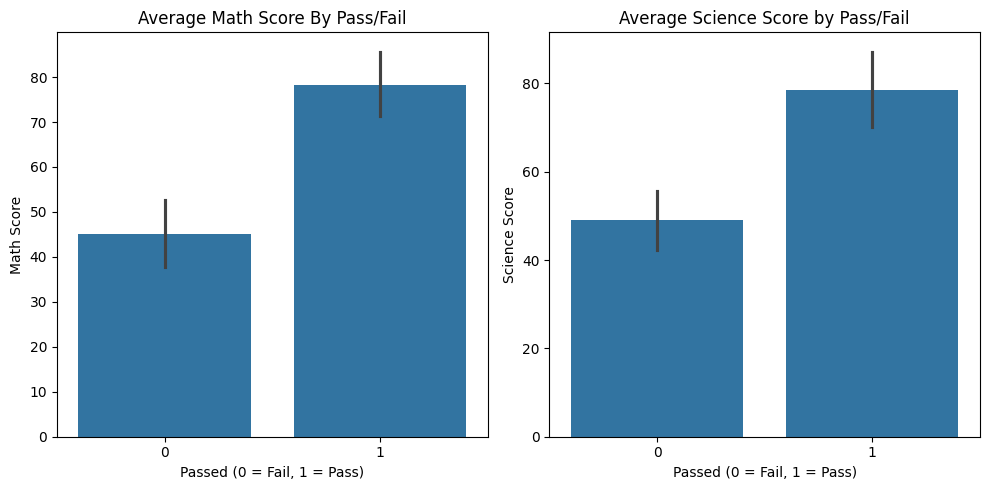

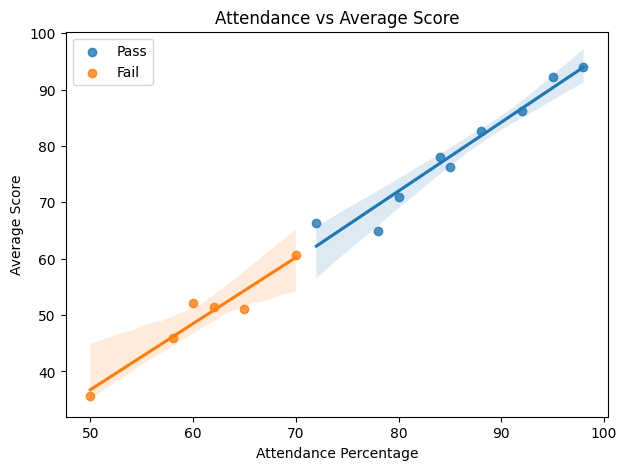

In [ ]:
#Task 3 — Data Visualization with Seaborn
# ------------------------
# Seaborn Bar Plot
# ------------------------

import seaborn as sns
import matplotlib.pyplot as plt

# 1.  Create figure with 2 Subplots
plt.figure(figsize=(10,5))

# First Subplot - Math
ax1 = plt.subplot(1, 2, 1)
sns.barplot(
    data = df,
    x="passed",
    y="math",
    ax=ax1
)

ax1.set_title("Average Math Score By Pass/Fail")
ax1.set_xlabel("Passed (0 = Fail, 1 = Pass)")
ax1.set_ylabel("Math Score")

# Second subplot — Science
ax2 = plt.subplot(1, 2, 2)

sns.barplot(
    data=df,
    x="passed",
    y="science",
    ax=ax2
)

ax2.set_title("Average Science Score by Pass/Fail")
ax2.set_xlabel("Passed (0 = Fail, 1 = Pass)")
ax2.set_ylabel("Science Score")

# Adjust layout
plt.tight_layout()

# Save plot
plt.savefig("plot6_seaborn_bar.png")

# Show plot
plt.show()

# 2. Seaborn Scatter Plot

plt.figure(figsize=(7, 5))

# Regression for passing students
sns.regplot(
    data=df[df["passed"] == 1],
    x="attendance_pct",
    y="avg_score",
    label="Pass"
)

# Regression for failing students
sns.regplot(
    data=df[df["passed"] == 0],
    x="attendance_pct",
    y="avg_score",
    label="Fail"
)

plt.title("Attendance vs Average Score")
plt.xlabel("Attendance Percentage")
plt.ylabel("Average Score")

plt.legend()

# Save plot
plt.savefig("plot7_seaborn_scatter.png")

plt.show()

# Seaborn was easier to use for statistical visualizations because it automatically calculated averages and adds regression lines with minimal code.
# Matplotlib required more manual setup but provided greater control over customization of plots

Training samples: 12
Testing Samples: 3

Training Model

Training Accuracy: 100.0 %

Test Accuracy: 100.0 %

Prediction Results:
---------------------------------------------
Jack | Actual: 0 | Predicted: 0 | ✅ correct
Liam | Actual: 0 | Predicted: 0 | ✅ correct
Alice | Actual: 1 | Predicted: 1 | ✅ correct

Feature Importance (sorted):
--------------------------------
english                   0.8125
attendance_pct            0.5219
study_hours_per_day       0.4844
pe                        0.4750
math                      0.4379
science                   0.3230
history                   0.2629


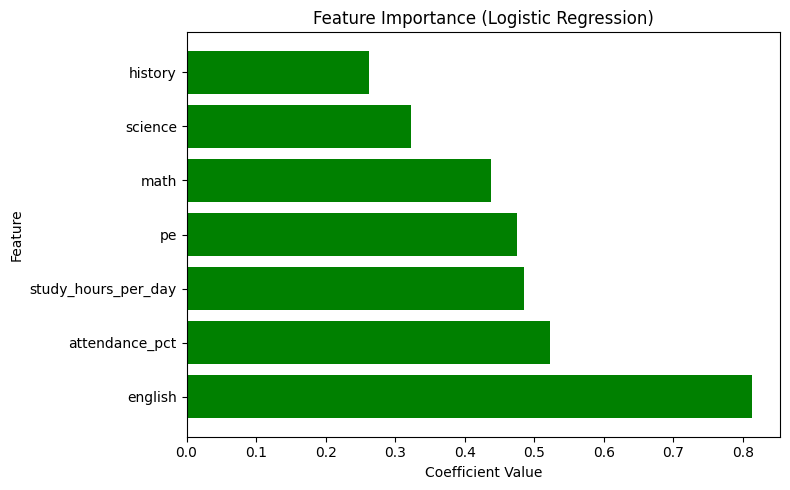


New Student Prediction:
-----------------------
Predicted Result: Pass
Probability (Fail, Pass): [[0.09203526 0.90796474]]


C:\Users\plsha\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [28]:
# Task 4 — Machine Learning with scikit-learn

# Step 1 — Prepare Data:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

#Define feature columns
feature_cols = [
    "math",
    "science",
    "english",
    "history",
    "pe",
    "attendance_pct",
    "study_hours_per_day"
]

# Separate features (x) and target (y)
X = df[feature_cols]
Y = df["passed"]

# Split into train and test sets(80/20)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
)

print("Training samples:" , len(X_train))
print("Testing Samples:" , len(X_test))

# Scale Features

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Step 2 — Train a Model:

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Create model
print("\nTraining Model")
model = LogisticRegression()

#  Train model
model.fit(X_train_scaled, y_train)

# Training accuracy
train_predictions = model.predict(X_train_scaled)

train_accuracy = accuracy_score(
    y_train,
    train_predictions
)

print("\nTraining Accuracy:", round(train_accuracy * 100, 2), "%")


# Step 3 — Evaluate the Model:

# Predict on test set
test_predictions = model.predict(X_test_scaled)

# Test accuracy
test_accuracy = accuracy_score(
    y_test,
    test_predictions
)

print("\nTest Accuracy:", round(test_accuracy * 100, 2), "%")

# Show prediction results per student

print("\nPrediction Results:")
print("---------------------------------------------")

for i in range(len(test_predictions)):

    student_name = df.loc[X_test.index[i], "name"]

    actual = y_test.iloc[i]
    predicted = test_predictions[i]

    if actual == predicted:
        status = "✅ correct"
    else:
        status = "❌ wrong"

    print(
        student_name,
        "| Actual:",
        actual,
        "| Predicted:",
        predicted,
        "|",
        status
    )


# Step 4 — Feature Importance

# ===============================
# Step 4 — Feature Importance
# ===============================

import matplotlib.pyplot as plt

# Get coefficients
coefficients = model.coef_[0]

# Pair features with coefficients
feature_importance = list(
    zip(feature_cols, coefficients)
)

# Sort by absolute value (largest first)
feature_importance.sort(
    key=lambda x: abs(x[1]),
    reverse=True
)

print("\nFeature Importance (sorted):")
print("--------------------------------")

for feature, coef in feature_importance:
    print(f"{feature:25} {coef:.4f}")

# Horizontal Bar Chart — Feature Importance
# Prepare data for plotting

features = [item[0] for item in feature_importance]
values = [item[1] for item in feature_importance]

# Assign colors

colors = []

for v in values:
    if v > 0:
        colors.append("green")
    else:
        colors.append("red")

plt.figure(figsize=(8, 5))

plt.barh(
    features,
    values,
    color=colors
)

plt.title("Feature Importance (Logistic Regression)")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")

plt.tight_layout()

plt.show()

# Step 5 — Predict for a New Student
# ===============================
# Step 5 — Predict New Student
# ===============================

new_student = [
    [75, 70, 68, 65, 80, 82, 3.2]
]

# Scale new student data

new_student_scaled = scaler.transform(
    new_student
)

# Predict result

prediction = model.predict(
    new_student_scaled
)

# Predict probability

probability = model.predict_proba(
    new_student_scaled
)

# Display result

if prediction[0] == 1:
    result = "Pass"
else:
    result = "Fail"

print("\nNew Student Prediction:")
print("-----------------------")

print("Predicted Result:", result)

print(
    "Probability (Fail, Pass):",
    probability
)

